# Exercises in Data Transformation and Exploratory Data Analysis

This notebook contains the exercises for the class of February 5, 2025, in the course Data & Things at Roskilde University.

In [258]:
import numpy
import pandas
import matplotlib.pyplot as plot
import seaborn

## Exercise 1

Plot the number of Cinemas in Danmark over the years. The next cell loads in the needed data for you if you have the file "DK_cinemas.csv" in the same folder as this notebook. 

In [259]:
cinema_data = pandas.read_csv('DK_cinemas.csv', sep=";")
years = cinema_data["Year"].tolist()
cinemas = cinema_data["Cinemas"].tolist()

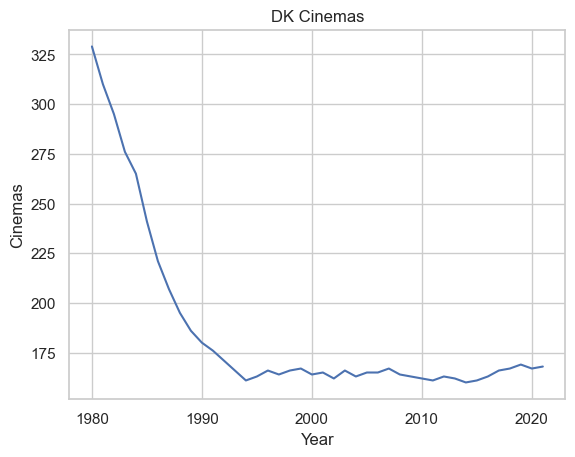

In [260]:
plot.plot(years, cinemas)
plot.xlabel("Year")
plot.ylabel("Cinemas")
plot.title("DK Cinemas")
plot.grid(True)
plot.show()

## Exercise 2

In this exercise, we are going to use the `penguins` dataset from the Seaborn package. The cell below loads the data

In [261]:

# Is already a data_frame
penguins_data = seaborn.load_dataset("penguins")

Based on the `Penguins` dataset, answer the following questions:

1. Make a barplot that shows how many penguins there are of each species in the dataset. Support the plot by calculating the numbers.
2. Make a barplot that shows the average body mass for each species of penguin. Support the plot by calculating the numbers
3. Make a boxplots that shows the distribution of the body mass for each species of penguin. Support the plot by calculating the numbers.
4. Make a scatterplot that shows the correlation between body mass (in g) and flipper length (in mm). Support the plot by calculating the numbers.
5. Use boxplots and histograms to show how bill length, bill depth, flipper length and body mass varies between species and sex.
6. Visualise how the linear correlation between body mass and flipper length varies between species and sex.

In [262]:
penguins_data

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


## 1. Make a barplot that shows how many penguins there are of each species in the dataset. Support the plot by calculating the numbers.

There is no need to not count the penguins with NaN measurements

species
Adelie       152
Chinstrap     68
Gentoo       124


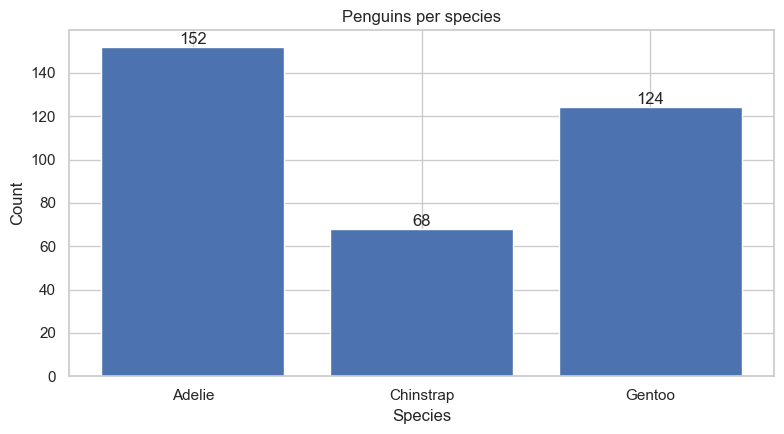

In [263]:

# Calculate counts (supporting numbers)
species_counts = (penguins_data["species"]
    .value_counts()
    .sort_index())

print(species_counts.to_string())

# Bar plot
fig, ax = plot.subplots(figsize=(8, 4.5))
bars = ax.bar(species_counts.index.tolist(), species_counts.values.tolist())

ax.set_title("Penguins per species")
ax.set_xlabel("Species")
ax.set_ylabel("Count")
ax.grid(True, axis="y")
ax.bar_label(bars)  # show counts on the bars

fig.tight_layout()
plot.show()

## 2. Make a barplot that shows the average body mass for each species of penguin. Support the plot by calculating the numbers

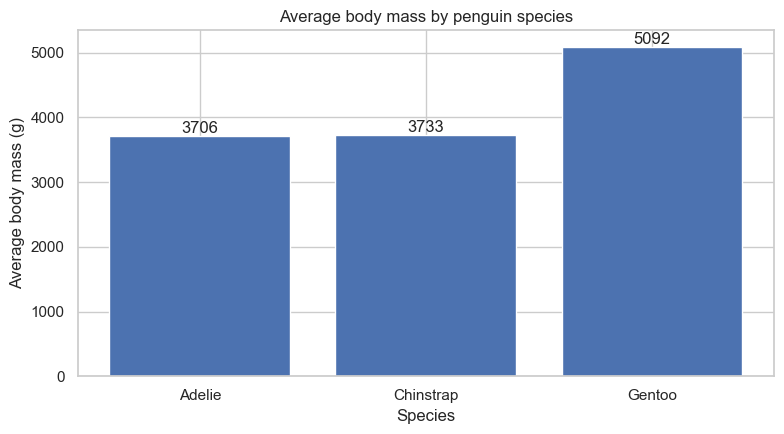

In [264]:
clean_data_frame = penguins_data.dropna(subset=["species", "sex", "body_mass_g", "flipper_length_mm"]).copy()

avg_mass = (
    clean_data_frame.groupby("species")["body_mass_g"]
            .mean()
            .sort_index()
)

fig, ax = plot.subplots(figsize=(8, 4.5))
bars = ax.bar(avg_mass.index.tolist(), avg_mass.values.tolist())

ax.set_title("Average body mass by penguin species")
ax.set_xlabel("Species")
ax.set_ylabel("Average body mass (g)")
ax.grid(True, axis="y")
ax.bar_label(bars, fmt="%.0f")  # show averages on bars

fig.tight_layout()
plot.show()

## 3. Make a boxplots that shows the distribution of the body mass for each species of penguin. Support the plot by calculating the numbers.

           count         mean         std     min     25%     50%     75%     max
species                                                                          
Adelie     146.0  3706.164384  458.620135  2850.0  3362.5  3700.0  4000.0  4775.0
Chinstrap   68.0  3733.088235  384.335081  2700.0  3487.5  3700.0  3950.0  4800.0
Gentoo     119.0  5092.436975  501.476154  3950.0  4700.0  5050.0  5500.0  6300.0


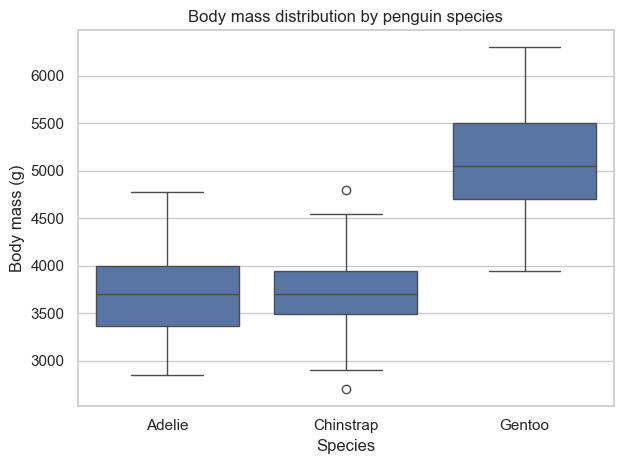

In [265]:
clean_data_frame = penguins_data.dropna(subset=["species", "sex", "body_mass_g", "flipper_length_mm"]).copy()

stats = (
    clean_data_frame.groupby("species")["body_mass_g"]
      .describe()
      .loc[:, ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
)

print(stats)

# Boxplot
seaborn.set_theme(style="whitegrid")
ax = seaborn.boxplot(data=clean_data_frame, x="species", y="body_mass_g")

ax.set_title("Body mass distribution by penguin species")
ax.set_xlabel("Species")
ax.set_ylabel("Body mass (g)")

plot.tight_layout()
plot.show()


## 4. Make a scatterplot that shows the correlation between body mass (in g) and flipper length (in mm). Support the plot by calculating the numbers.

       body_mass_g  flipper_length_mm
count   333.000000         333.000000
mean   4207.057057         200.966967
std     805.215802          14.015765
min    2700.000000         172.000000
25%    3550.000000         190.000000
50%    4050.000000         197.000000
75%    4775.000000         213.000000
max    6300.000000         231.000000
Pearson correlation (r):  0.8730
Spearman correlation (ρ): 0.8404


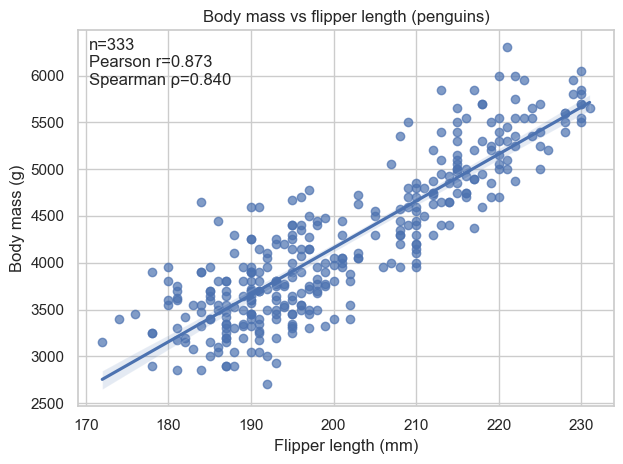

In [266]:
clean_data_frame = penguins_data.dropna(subset=["species", "sex", "body_mass_g", "flipper_length_mm"]).copy()

# Support numbers: descriptive stats for both variables
## .loc = labels
## .iloc = integer positions
stats = (
    clean_data_frame[["body_mass_g", "flipper_length_mm"]]
      .describe()
      # “keep all species rows, but only these statistic columns.”
      .loc[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
)

print(stats)

# Correlation (the key "number" behind the scatterplot)
pearson_corr = clean_data_frame["body_mass_g"].corr(clean_data_frame["flipper_length_mm"], method="pearson")
spearman_corr = clean_data_frame["body_mass_g"].corr(clean_data_frame["flipper_length_mm"], method="spearman")

print(f"Pearson correlation (r):  {pearson_corr:.4f}")
print(f"Spearman correlation (ρ): {spearman_corr:.4f}")

# Scatterplot (+ regression line to visualize correlation)
seaborn.set_theme(style="whitegrid")
ax = seaborn.regplot(
    data=clean_data_frame,
    x="flipper_length_mm",
    y="body_mass_g",
    scatter_kws={"alpha": 0.7}
)

ax.set_title("Body mass vs flipper length (penguins)")
ax.set_xlabel("Flipper length (mm)")
ax.set_ylabel("Body mass (g)")

# Optional: annotate the plot with correlation numbers
ax.text(
    0.02, 0.98,
    f"n={len(clean_data_frame)}\nPearson r={pearson_corr:.3f}\nSpearman ρ={spearman_corr:.3f}",
    transform=ax.transAxes,
    ha="left", va="top"
)

plot.tight_layout()
plot.show()

## 5. Use boxplots and histograms to show how bill length, bill depth, flipper length and body mass varies between species and sex.

In [267]:
# Optional but useful in notebooks
pandas.set_option("display.max_columns", None)
pandas.set_option("display.width", 140)

required_columns = {
    "species",
    "sex",
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
}

missing = required_columns.difference(penguins_data.columns)
if missing:
    raise ValueError(f"penguins_data is missing required columns: {sorted(missing)}")

seaborn.set_theme(style="whitegrid")

In [268]:
def get_category_orders(dataframe: pandas.DataFrame) -> tuple[list[str], list[str]]:
    species_order = sorted(dataframe["species"].dropna().unique().tolist())

    observed_sex = set(dataframe["sex"].dropna().unique().tolist())
    sex_order = [label for label in ["Female", "Male"] if label in observed_sex]

    if not sex_order:
        raise ValueError("No valid values found in 'sex' column after dropping NaNs.")

    return species_order, sex_order


def summarize_metric(dataframe: pandas.DataFrame, metric: str) -> pandas.DataFrame:
    summary_dataframe = (
        dataframe.dropna(subset=["species", "sex", metric])
        .groupby(["species", "sex"], observed=False)[metric]
        .describe()
        .loc[:, ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
        .rename(columns={"50%": "median"})
        .reset_index()
    )

    summary_dataframe.insert(0, "metric", metric)
    return summary_dataframe


def prepare_plot_dataframe(
    dataframe: pandas.DataFrame,
    metric: str,
    species_order: list[str],
    sex_order: list[str],
) -> pandas.DataFrame:
    plot_dataframe = dataframe.dropna(subset=["species", "sex", metric]).copy()

    plot_dataframe["species"] = pandas.Categorical(
        plot_dataframe["species"],
        categories=species_order,
        ordered=True,
    )

    plot_dataframe["sex"] = pandas.Categorical(
        plot_dataframe["sex"],
        categories=sex_order,
        ordered=True,
    )

    return plot_dataframe


def plot_metric_boxplot(
    plot_dataframe: pandas.DataFrame,
    metric: str,
    species_order: list[str],
    sex_order: list[str],
) -> None:
    figure, axis = plot.subplots(figsize=(9, 4.8))

    seaborn.boxplot(
        data=plot_dataframe,
        x="species",
        y=metric,
        hue="sex",
        order=species_order,
        hue_order=sex_order,
        ax=axis,
    )

    axis.set_title(f"{metric}: distribution by species and sex (boxplot)")
    axis.set_xlabel("Species")
    axis.set_ylabel(metric)
    axis.grid(True, axis="y")

    legend = axis.get_legend()
    if legend is not None:
        legend.set_title("Sex")
        legend.set_frame_on(True)

    figure.tight_layout()
    plot.show()


def plot_metric_histograms(
    plot_dataframe: pandas.DataFrame,
    metric: str,
    sex_order: list[str],
) -> None:
    grid = seaborn.displot(
        data=plot_dataframe,
        x=metric,
        col="sex",
        col_order=sex_order,
        hue="species",
        kind="hist",
        bins="auto",
        element="step",
        stat="count",
        common_norm=False,
        height=3.6,
        aspect=1.25,
    )

    grid.set_axis_labels(metric, "Count")
    grid.set_titles(col_template="Sex: {col_name}")
    grid.figure.suptitle(f"{metric}: distribution by species within each sex (histograms)", y=1.03)
    grid.figure.tight_layout()
    plot.show()


species_order, sex_order = get_category_orders(penguins_data)

### Bill_Length

,metric,species,sex,count,mean,std,min,25%,median,75%,max
0,bill_length_mm,Adelie,Female,73.0,37.257534,2.028883,32.1,35.900,37.00,38.800,42.2
1,bill_length_mm,Adelie,Male,73.0,40.390411,2.277131,34.6,39.000,40.60,41.500,46.0
2,bill_length_mm,Chinstrap,Female,34.0,46.573529,3.108669,40.9,45.425,46.30,47.375,58.0
3,bill_length_mm,Chinstrap,Male,34.0,51.094118,1.564558,48.5,50.050,50.95,51.975,55.8
4,bill_length_mm,Gentoo,Female,58.0,45.563793,2.051247,40.9,43.850,45.50,46.875,50.5
5,bill_length_mm,Gentoo,Male,61.0,49.473770,2.720594,44.4,48.100,49.50,50.500,59.6


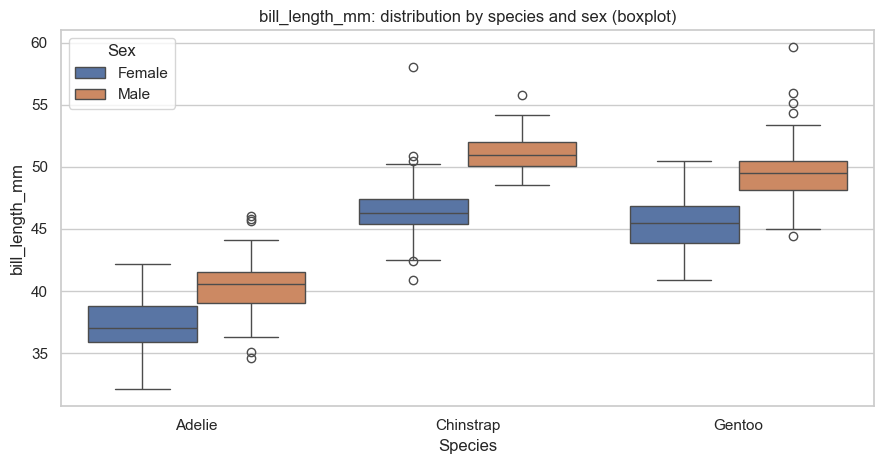

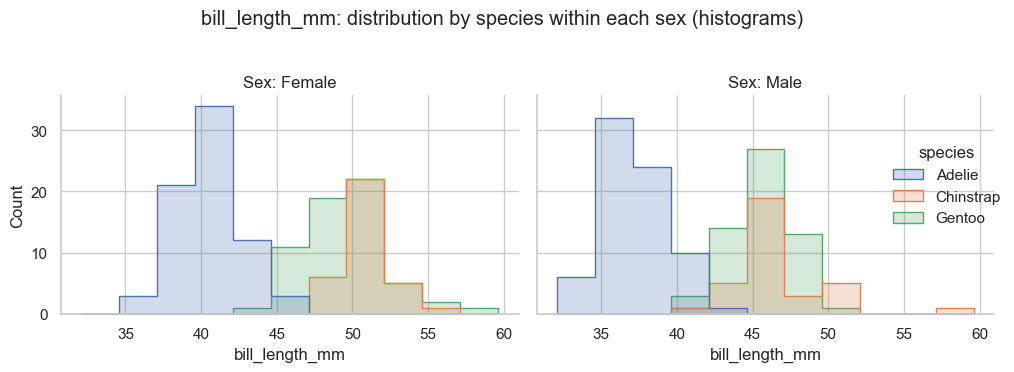

In [269]:
bill_length_summary = summarize_metric(penguins_data, "bill_length_mm")
display(bill_length_summary)

bill_length_plot_dataframe = prepare_plot_dataframe(
    penguins_data,
    metric="bill_length_mm",
    species_order=species_order,
    sex_order=sex_order,
)

plot_metric_boxplot(
    bill_length_plot_dataframe,
    metric="bill_length_mm",
    species_order=species_order,
    sex_order=sex_order,
)

plot_metric_histograms(
    bill_length_plot_dataframe,
    metric="bill_length_mm",
    sex_order=sex_order,
)

### Bill Depth

,metric,species,sex,count,mean,std,min,25%,median,75%,max
0,bill_depth_mm,Adelie,Female,73.0,17.621918,0.942993,15.5,17.0,17.60,18.30,20.7
1,bill_depth_mm,Adelie,Male,73.0,19.072603,1.018886,17.0,18.5,18.90,19.60,21.5
2,bill_depth_mm,Chinstrap,Female,34.0,17.588235,0.781128,16.4,17.0,17.65,18.05,19.4
3,bill_depth_mm,Chinstrap,Male,34.0,19.252941,0.761273,17.5,18.8,19.30,19.80,20.8
4,bill_depth_mm,Gentoo,Female,58.0,14.237931,0.540249,13.1,13.8,14.25,14.60,15.5
5,bill_depth_mm,Gentoo,Male,61.0,15.718033,0.741060,14.1,15.2,15.70,16.10,17.3


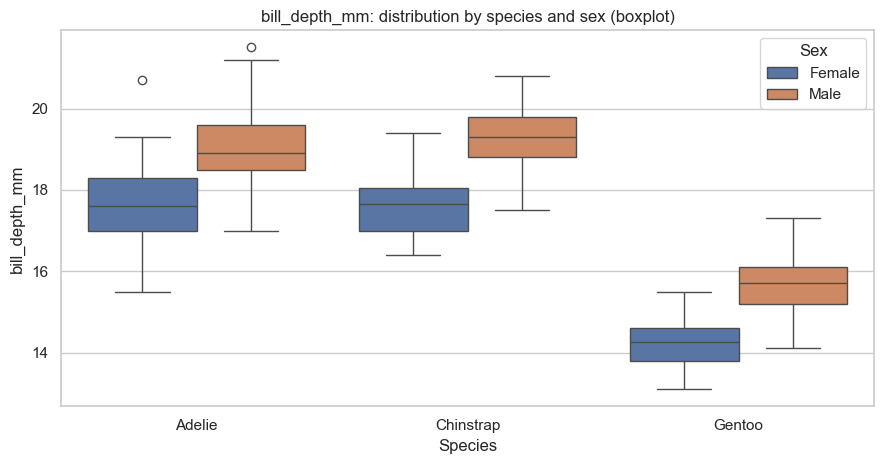

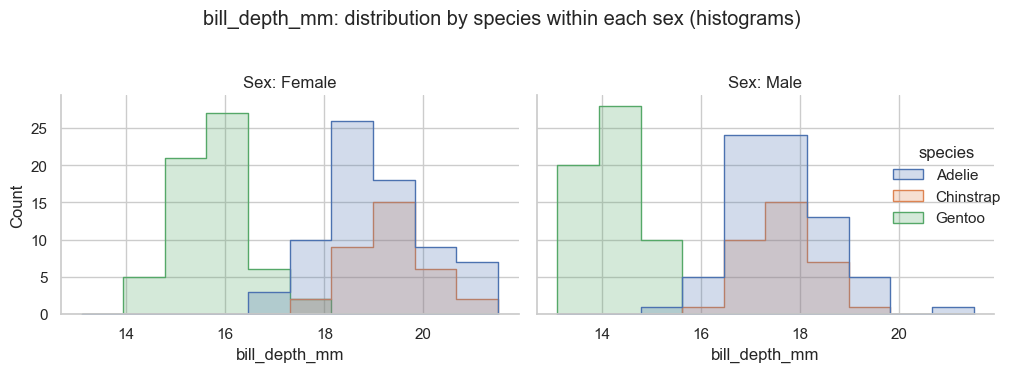

In [270]:
bill_depth_summary = summarize_metric(penguins_data, "bill_depth_mm")
display(bill_depth_summary)

bill_depth_plot_dataframe = prepare_plot_dataframe(
    penguins_data,
    metric="bill_depth_mm",
    species_order=species_order,
    sex_order=sex_order,
)

plot_metric_boxplot(
    bill_depth_plot_dataframe,
    metric="bill_depth_mm",
    species_order=species_order,
    sex_order=sex_order,
)

plot_metric_histograms(
    bill_depth_plot_dataframe,
    metric="bill_depth_mm",
    sex_order=sex_order,
)

### Flipper Length

,metric,species,sex,count,mean,std,min,25%,median,75%,max
0,flipper_length_mm,Adelie,Female,73.0,187.794521,5.595035,172.0,185.00,188.0,191.00,202.0
1,flipper_length_mm,Adelie,Male,73.0,192.410959,6.599317,178.0,189.00,193.0,197.00,210.0
2,flipper_length_mm,Chinstrap,Female,34.0,191.735294,5.754096,178.0,187.25,192.0,195.75,202.0
3,flipper_length_mm,Chinstrap,Male,34.0,199.911765,5.976558,187.0,196.00,200.5,203.00,212.0
4,flipper_length_mm,Gentoo,Female,58.0,212.706897,3.897856,203.0,210.00,212.0,215.00,222.0
5,flipper_length_mm,Gentoo,Male,61.0,221.540984,5.673252,208.0,218.00,221.0,225.00,231.0


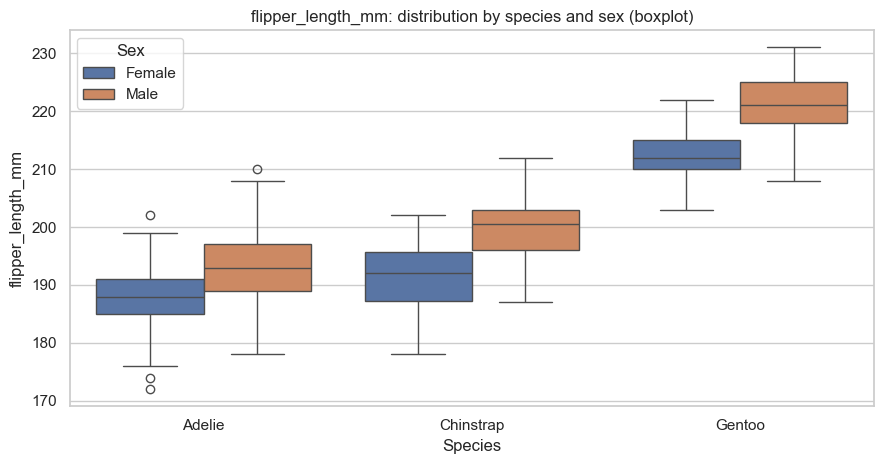

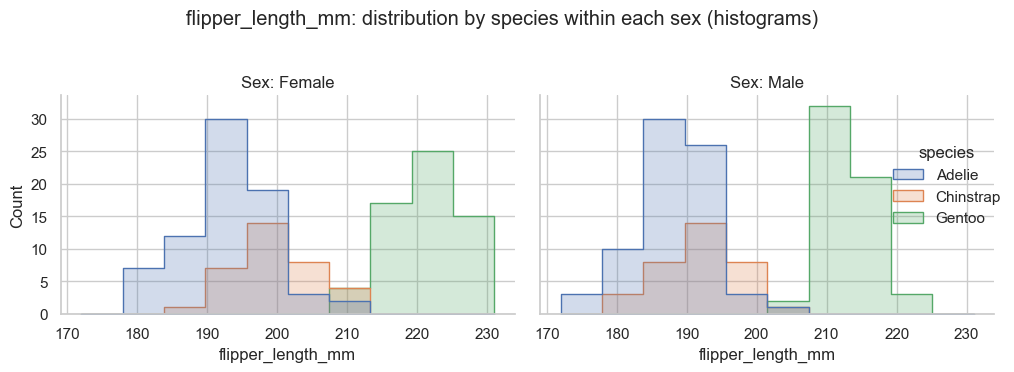

In [271]:
flipper_length_summary = summarize_metric(penguins_data, "flipper_length_mm")
display(flipper_length_summary)

flipper_length_plot_dataframe = prepare_plot_dataframe(
    penguins_data,
    metric="flipper_length_mm",
    species_order=species_order,
    sex_order=sex_order,
)

plot_metric_boxplot(
    flipper_length_plot_dataframe,
    metric="flipper_length_mm",
    species_order=species_order,
    sex_order=sex_order,
)

plot_metric_histograms(
    flipper_length_plot_dataframe,
    metric="flipper_length_mm",
    sex_order=sex_order,
)

### Body Mass

,metric,species,sex,count,mean,std,min,25%,median,75%,max
0,body_mass_g,Adelie,Female,73.0,3368.835616,269.380102,2850.0,3175.00,3400.0,3550.00,3900.0
1,body_mass_g,Adelie,Male,73.0,4043.493151,346.811553,3325.0,3800.00,4000.0,4300.00,4775.0
2,body_mass_g,Chinstrap,Female,34.0,3527.205882,285.333912,2700.0,3362.50,3550.0,3693.75,4150.0
3,body_mass_g,Chinstrap,Male,34.0,3938.970588,362.137550,3250.0,3731.25,3950.0,4100.00,4800.0
4,body_mass_g,Gentoo,Female,58.0,4679.741379,281.578294,3950.0,4462.50,4700.0,4875.00,5200.0
5,body_mass_g,Gentoo,Male,61.0,5484.836066,313.158596,4750.0,5300.00,5500.0,5700.00,6300.0


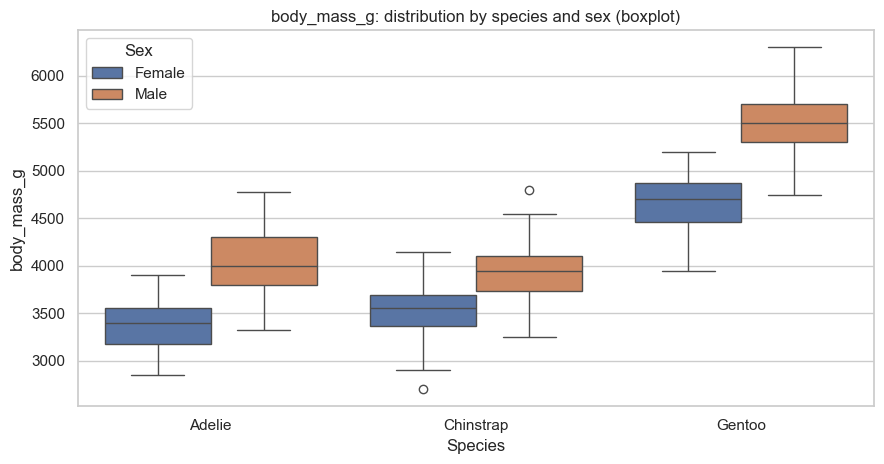

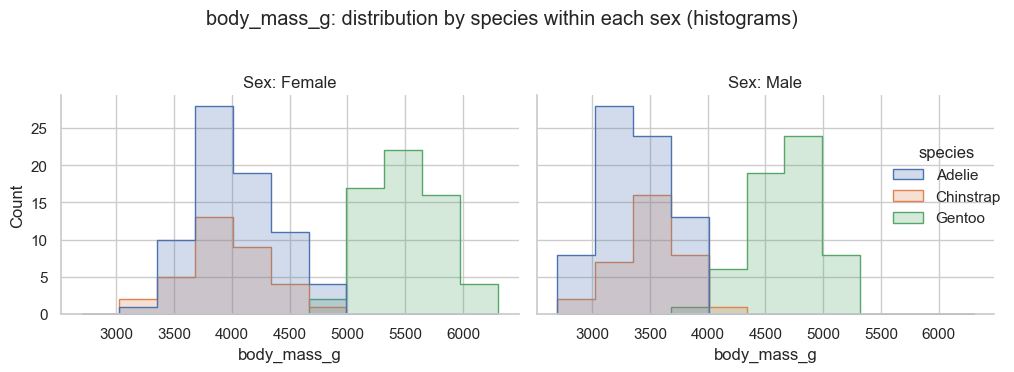

In [272]:
body_mass_summary = summarize_metric(penguins_data, "body_mass_g")
display(body_mass_summary)

body_mass_plot_dataframe = prepare_plot_dataframe(
    penguins_data,
    metric="body_mass_g",
    species_order=species_order,
    sex_order=sex_order,
)

plot_metric_boxplot(
    body_mass_plot_dataframe,
    metric="body_mass_g",
    species_order=species_order,
    sex_order=sex_order,
)

plot_metric_histograms(
    body_mass_plot_dataframe,
    metric="body_mass_g",
    sex_order=sex_order,
)

### Summary

In [273]:
summary = pandas.concat(
    [
        bill_length_summary,
        bill_depth_summary,
        flipper_length_summary,
        body_mass_summary,
    ],
    ignore_index=True,
)

print(summary.to_string(index=False))

           metric   species    sex  count        mean        std    min      25%  median      75%    max
   bill_length_mm    Adelie Female   73.0   37.257534   2.028883   32.1   35.900   37.00   38.800   42.2
   bill_length_mm    Adelie   Male   73.0   40.390411   2.277131   34.6   39.000   40.60   41.500   46.0
   bill_length_mm Chinstrap Female   34.0   46.573529   3.108669   40.9   45.425   46.30   47.375   58.0
   bill_length_mm Chinstrap   Male   34.0   51.094118   1.564558   48.5   50.050   50.95   51.975   55.8
   bill_length_mm    Gentoo Female   58.0   45.563793   2.051247   40.9   43.850   45.50   46.875   50.5
   bill_length_mm    Gentoo   Male   61.0   49.473770   2.720594   44.4   48.100   49.50   50.500   59.6
    bill_depth_mm    Adelie Female   73.0   17.621918   0.942993   15.5   17.000   17.60   18.300   20.7
    bill_depth_mm    Adelie   Male   73.0   19.072603   1.018886   17.0   18.500   18.90   19.600   21.5
    bill_depth_mm Chinstrap Female   34.0   17.588235  

## 6. Visualise how the linear correlation between body mass and flipper length varies between species and sex.

  species    sex    n  pearson_r  spearman_rho     slope    intercept       r2
   Adelie Female 73.0   0.262930      0.244893 12.659084   991.529057 0.069132
   Adelie   Male 73.0   0.360434      0.401107 18.941783   398.886433 0.129913
Chinstrap Female 34.0   0.242150      0.258367 12.007726  1224.901074 0.058637
Chinstrap   Male 34.0   0.664588      0.675582 40.269356 -4111.347531 0.441677
   Gentoo Female 58.0   0.487618      0.526639 35.225169 -2812.894941 0.237771
   Gentoo   Male 61.0   0.330452      0.354693 18.240662  1443.781834 0.109199


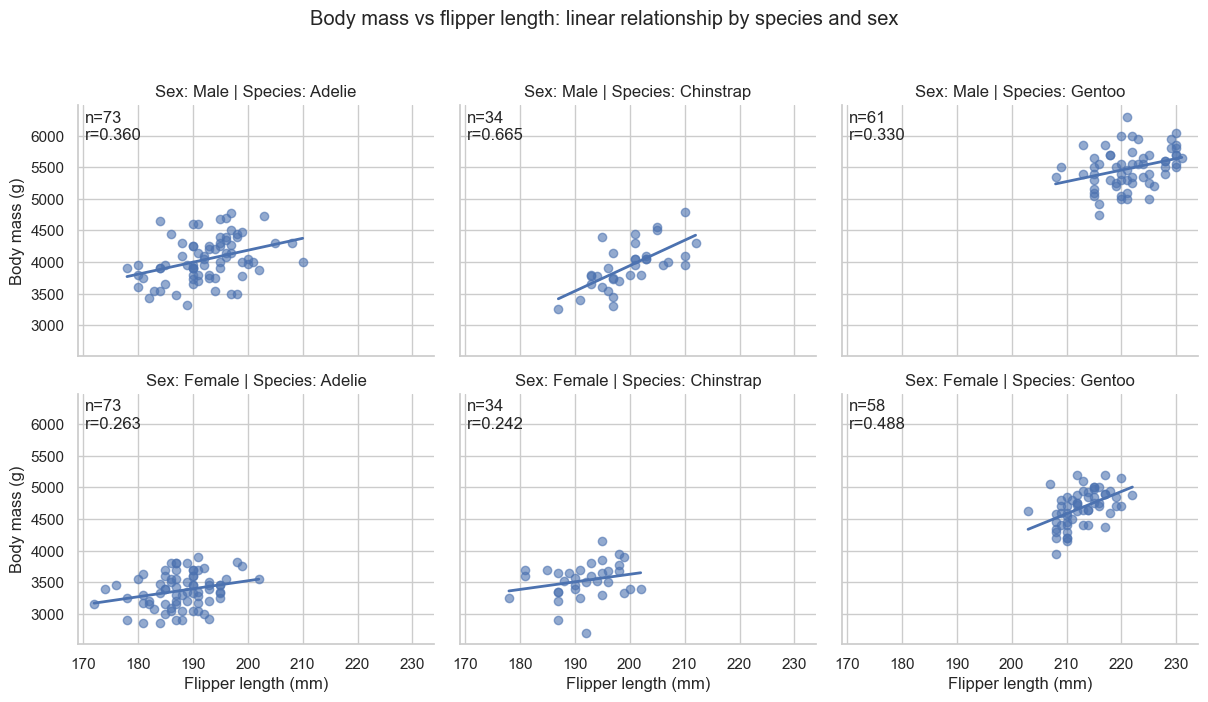

In [274]:
# Clean only what we need
clean_data_frame = penguins_data.dropna(
    subset=["species", "sex", "body_mass_g", "flipper_length_mm"]
).copy()

# ----------------------------
# Support numbers (per species + sex)
# ----------------------------
def corr_and_fit(group: pandas.DataFrame) -> pandas.Series:
    x = group["flipper_length_mm"].to_numpy(dtype=float)
    y = group["body_mass_g"].to_numpy(dtype=float)
    n = len(group)

    if n < 2:
        return pandas.Series({
            "n": n,
            "pearson_r": numpy.nan,
            "spearman_rho": numpy.nan,
            "slope": numpy.nan,
            "intercept": numpy.nan,
            "r2": numpy.nan
        })

    pearson_r = float(numpy.corrcoef(x, y)[0, 1])
    spearman_rho = float(pandas.Series(x).corr(pandas.Series(y), method="spearman"))

    slope, intercept = numpy.polyfit(x, y, 1)
    y_hat = slope * x + intercept

    ss_res = float(numpy.sum((y - y_hat) ** 2))
    ss_tot = float(numpy.sum((y - numpy.mean(y)) ** 2))
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else numpy.nan

    return pandas.Series({
        "n": n,
        "pearson_r": pearson_r,
        "spearman_rho": spearman_rho,
        "slope": slope,
        "intercept": intercept,
        "r2": r2
    })

corr_table = (
    clean_data_frame
    .groupby(["species", "sex"], dropna=False)
    .apply(corr_and_fit)
    .reset_index()
    .sort_values(["species", "sex"])
)

print(corr_table.to_string(index=False))

# ----------------------------
# Visualisation: correlation varies by species AND sex
# ----------------------------
seaborn.set_theme(style="whitegrid")

grid = seaborn.lmplot(
    data=clean_data_frame,
    x="flipper_length_mm",
    y="body_mass_g",
    row="sex",
    col="species",
    height=3.4,
    aspect=1.2,
    scatter_kws={"alpha": 0.6},
    line_kws={"linewidth": 2},
    ci=None
)

grid.set_axis_labels("Flipper length (mm)", "Body mass (g)")
grid.set_titles(row_template="Sex: {row_name}", col_template="Species: {col_name}")

# Annotate each facet with n and Pearson r
for (sex_value, species_value), axis in grid.axes_dict.items():
    subset = clean_data_frame[
        (clean_data_frame["sex"] == sex_value) &
        (clean_data_frame["species"] == species_value)
    ]

    n = len(subset)

    if n >= 2:
        r = subset["body_mass_g"].corr(subset["flipper_length_mm"], method="pearson")
        axis.text(
            0.02, 0.98,
            f"n={n}\nr={r:.3f}",
            transform=axis.transAxes,
            ha="left",
            va="top"
        )
    else:
        axis.text(
            0.02, 0.98,
            f"n={n}",
            transform=axis.transAxes,
            ha="left",
            va="top"
        )

grid.fig.suptitle(
    "Body mass vs flipper length: linear relationship by species and sex",
    y=1.03
)

plot.tight_layout()
plot.show()

## Exercise 3

Do an exploratory data analysis of the adult dataset. The cell below loads the dataset from UCI Machine Learning Repository into a pandas dataframe called `adult_data`. It requires that you have installed the package `ucimlrepo`. (Otherwise the dataset is on moodle page for this class.)

In [275]:
from ucimlrepo import fetch_ucirepo 
adult = fetch_ucirepo(id=2) 
X = adult.data.features 
y = adult.data.targets 
X["income"] = y
adult_data = X.copy()

adult_data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


### 1. What does the dataset look like? (columns, types, missing values, duplicates)

In [276]:
# Create a clean working copy
adult_dataframe = adult_data.copy()

In [277]:
print("Columns:")
print(list(adult_dataframe.columns))

print("\nData types:")
print(adult_dataframe.dtypes)

print("\nMissing values:")
missing_value_counts = adult_dataframe.isna().sum().sort_values(ascending=False)
missing_value_percentages = (missing_value_counts / len(adult_dataframe) * 100).round(2)
missing_value_report = pandas.DataFrame(
    {
        "missing_count": missing_value_counts,
        "missing_pct": missing_value_percentages
    }
)
display(missing_value_report[missing_value_report["missing_count"] > 0])

duplicate_row_count = adult_dataframe.duplicated().sum()
print("\nDuplicate rows:", duplicate_row_count)

Columns:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Data types:
age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
dtype: object

Missing values:


,missing_count,missing_pct
occupation,966,1.98
workclass,963,1.97
native-country,274,0.56



Duplicate rows: 29


### 2. What are the numeric and categorical features?

In [ ]:
numeric_feature_names = adult_dataframe.select_dtypes(include=["number"]).columns.tolist()

# Exlucding "fnlwgt", "capital-gain", "capital-loss"
numeric_feature_names = [
    feature_name
    for feature_name in numeric_feature_names
    if feature_name not in ["fnlwgt", "capital-gain", "capital-loss"]
]

categorical_feature_names = [
    feature_name for feature_name in adult_dataframe.columns
    if feature_name not in numeric_feature_names
]

print("Numeric features:")
print(numeric_feature_names)

print("\nCategorical features:")
print(categorical_feature_names)

Numeric features:
['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical features:
['workclass', 'fnlwgt', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


### 3. What are the summary statistics for numeric features?

In [279]:
display(adult_dataframe[numeric_feature_names].describe().T)

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


### 4. What are the summary statistics for categorical features?

In [280]:
categorical_summary_table = pandas.DataFrame(
    {
        "data_type": adult_dataframe[categorical_feature_names].dtypes.astype(str),
        "unique_values": [adult_dataframe[feature_name].nunique(dropna=True) for feature_name in categorical_feature_names],
        "missing_values": [adult_dataframe[feature_name].isna().sum() for feature_name in categorical_feature_names],
        "most_common_value": [
            adult_dataframe[feature_name].mode(dropna=True).iloc[0]
            if not adult_dataframe[feature_name].mode(dropna=True).empty
            else numpy.nan
            for feature_name in categorical_feature_names
        ],
        "most_common_count": [
            adult_dataframe[feature_name].value_counts(dropna=True).iloc[0]
            if not adult_dataframe[feature_name].dropna().empty
            else numpy.nan
            for feature_name in categorical_feature_names
        ]
    },
    index=categorical_feature_names
).sort_values("unique_values", ascending=False)

display(categorical_summary_table)

,data_type,unique_values,missing_values,most_common_value,most_common_count
fnlwgt,int64,28523,0,203488,21
native-country,str,42,274,United-States,43832
education,str,16,0,HS-grad,15784
occupation,str,15,966,Prof-specialty,6172
workclass,str,9,963,Private,33906
marital-status,str,7,0,Married-civ-spouse,22379
relationship,str,6,0,Husband,19716
race,str,5,0,White,41762
income,str,4,0,<=50K,24720
sex,str,2,0,Male,32650


### 5. What do the numeric feature distributions look like?

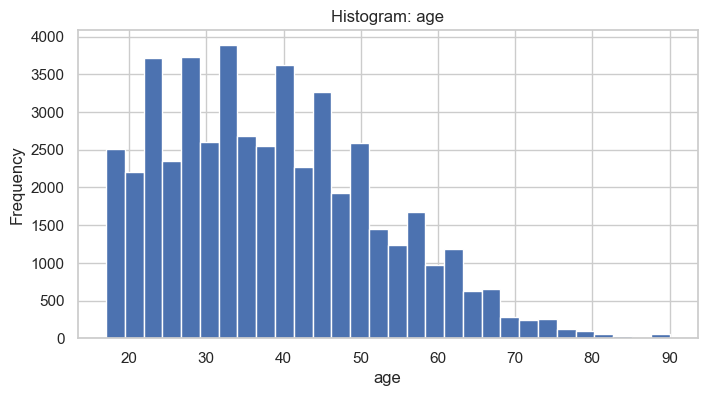

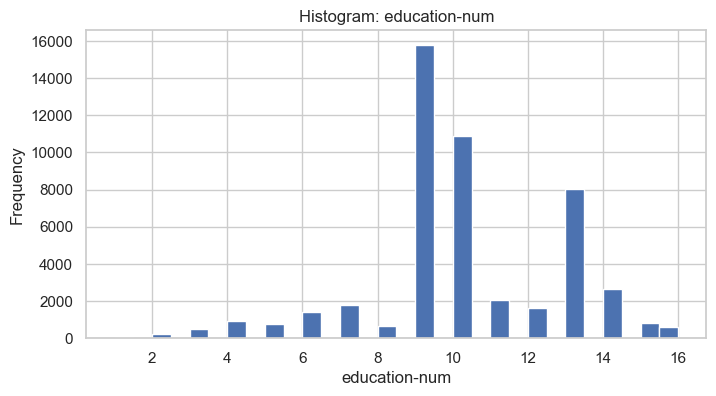

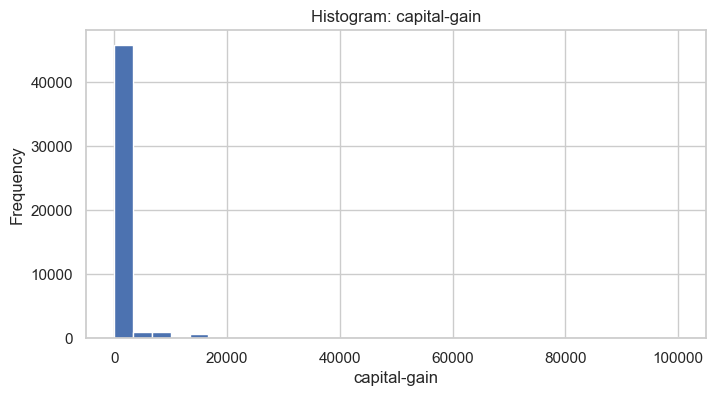

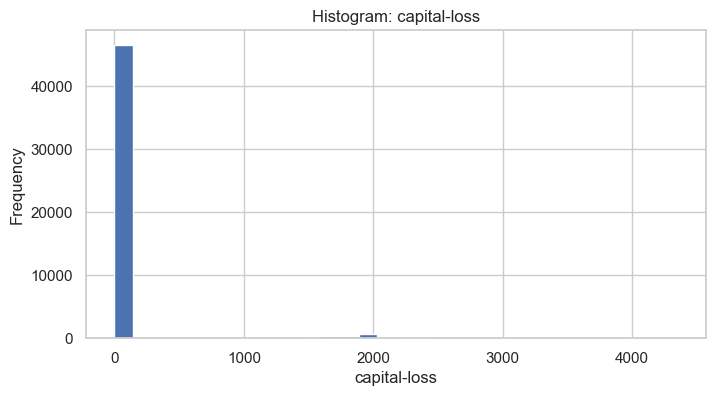

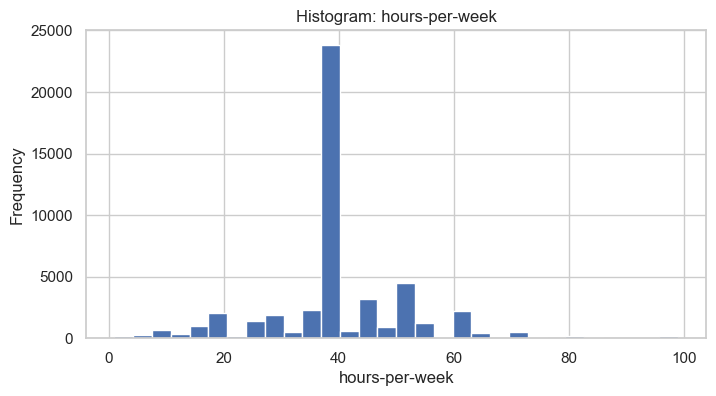

In [281]:
for numeric_feature_name in numeric_feature_names:
    histogram_figure, histogram_axis = plot.subplots(figsize=(8, 4))
    adult_dataframe[numeric_feature_name].dropna().plot(kind="hist", bins=30, ax=histogram_axis)
    histogram_axis.set_title(f"Histogram: {numeric_feature_name}")
    histogram_axis.set_xlabel(numeric_feature_name)
    histogram_axis.set_ylabel("Frequency")
    plot.show()

### 5. What is the income distribution

,count,pct
income,,
<=50K,24720,50.61
<=50K.,12435,25.46
>50K,7841,16.05
>50K.,3846,7.87


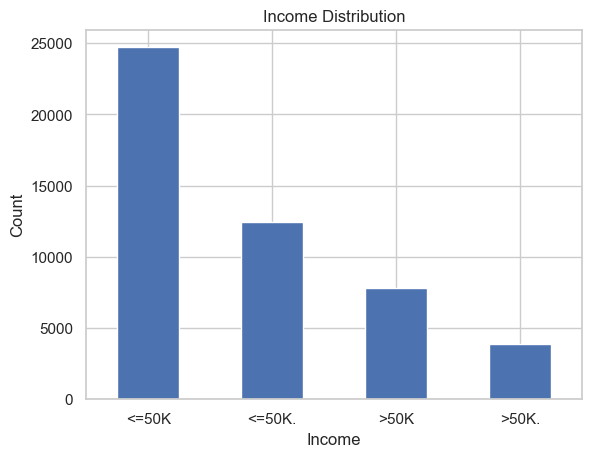

In [282]:
income_distribution = adult_dataframe["income"].value_counts(dropna=False)
income_distribution_percentages = (adult_dataframe["income"].value_counts(normalize=True, dropna=False) * 100).round(2)

income_distribution_table = pandas.DataFrame(
    {
        "count": income_distribution,
        "pct": income_distribution_percentages
    }
)

display(income_distribution_table)

income_distribution_axis = adult_dataframe["income"].value_counts().plot(kind="bar", rot=0)
income_distribution_axis.set_title("Income Distribution")
income_distribution_axis.set_xlabel("Income")
income_distribution_axis.set_ylabel("Count")
plot.show()

## Exercise 4 (Optional)

Complete an exploratory data analysis of the titanic dataset (it is on moodle). (Remember, you can load it in as `titanic_data = pd.read_csv("titanic_survival_data.csv")`)

## Exercise 5 (Optional)

Do an exploratory data analysis of the diabetes dataset. The cell below loads the dataset from the scikit learn package into the pandas dataframe called `diabetes_data`.

In [283]:
from sklearn.datasets import load_diabetes
d_data = load_diabetes(as_frame=True)
diabetes_data = d_data.data
diabetes_data["Target"] = d_data.target

diabetes_data

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0
